# MAPDB-project 

# Beccarelli Cesare, Lui Riccardo, Schiavinato Alberto

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# Analysis of the minibatch algorithm
The target of our evaluation have been the inertia at the last iteration in order to evaluate the quality of clustering and the total time.
The actual algorithm has been run on files .py on the cluster t consists in an initialization that reflects the work of Bahmani et al., "Scalable K-means++" (2012), and a minibatch kmeans. Both algorithms are distributed in blocks to the workers, where the heavy computation is made. 
In order to find the best hyperparameters for the algorithms, we tested different architectures and performed a grid search analysis, saving total execution time and inertia as the two measures we want to focus our optimization on.

The inertia is defined as usually the sum of the norms of the points from their closest centroid, while for the total execution time we consider both the initialization and the k-means algorithm. We consider the inertia to have a bigger weight on the overall performance of the algorithm, but we also try to minimize the tradeoff with time.

The initialization phase implements the k-means|| algorithm proposed by Bahmani et al., which is a parallelizable approximation of k-means++. Starting from a single randomly chosen center, the algorithm proceeds in r distributed rounds to compute the potential $\varphi$ (inertia of the initialization). That quantity is then used to compute the sampling probability $p_t(x)$ to be added to the canditate set at iteration t
$$
p_t(x) = \min\left( \frac{\ell D_t(x)}{\phi_t}, 1 \right)
$$

$\ell$ is the oversampling factor, which helps in getting the tradeoff between computation time and quality of the initialization.
After r rounds, the algorithm produces a candidate set C  much smaller than the dataset but good enough to approximate k-means++ seeding. A local weighted k-means is then run on C, weighing each candidate by the number of original points assigned to it, to reduce the dimensionality of the set to k initial centroids. 

Once the initialization is completed and the number of centroids is reduced, the points are then assigned to these clusters using minibatch k-means. In particular in our version, we implemented a block-wise minibatch, to have a speedup on the computations, while trying to guarantee accuracy. We thus sampled points uniformally from the blocks distributed across each worker, to avoid index shuffling between workers while sampling from the dataset.

$$
c_j^{(t+1)} = \bigl(1 - \eta_j^{(t)}\bigr)\, c_j^{(t)}
            + \eta_j^{(t)} \, \bar{x}_j^{(t)}
$$

with $\bar{x}_j^{(t)}$ the mean of minibatch points assigned to cluster j. For each cluster j, we updated the center according to a learning rate weighted by the dimension of the group, to avoid biasing towards larger clusters.

Regarding the dataset the original one contains some cathegorical variable needs to be translated in one hot encoding beform perform the actual clustering. So in order to preprocess the dataset essentially scaling it, converting cathegoricals columns in one hot encoding. This lead us to a dataset of a dimensionality of 122 (starting one was 41) and size of approx 4.8e7 

We now present the analysis over the grid search of the hyperparameters namely:
k: clustering size,
blk: block size,
bs: batch size,
r: rounds, 
mc: max candidates of the oversampling passage and 
vms: number of virtual machine used, workers: number of workers

### Loading the dataset
the result of the different runs had been converted in a dataframe using the makepd notebook in order to have a ready to use dataframe. In this context we load the dataframe and drop columns of variable that are outside the scope of our analysis. Then we look at the best general runs for what concerns inertia and total time.

In [57]:
# Import the dataset
df_tot = pd.read_csv("dataframez/Runs_outputs_total_final.csv")
df_tot = df_tot.drop(columns=["folder", "centroids","cr"])
df_tot.head()

,Unnamed: 0,k,blk,bs,r,l,mc,it,vms,workers,total_time,inertia_full,mean_dist,median_dist,max_dist
0,0,20,16,25000,7,20,5000,20,4,8,54.28,412750800.0,61.4015,44.4853,293.611
1,1,20,16,200000,5,40,5000,5,4,8,37.00,410768000.0,60.0352,68.0685,202.071
2,2,20,24,100000,5,40,5000,10,4,8,41.82,392829900.0,169.0800,68.2070,1961.690
3,3,20,16,200000,6,10,5000,10,4,8,46.62,395943000.0,225.0170,35.8214,1961.710
4,4,35,16,100000,7,35,5000,20,4,8,67.18,331425600.0,57.2062,68.1928,181.993


In [58]:
#Let's inspect the best runs for Time and Inertia
best_inertia = df_tot.loc[df_tot["inertia_full"].idxmin()]
best_time = df_tot.loc[df_tot["total_time"].idxmin()]

In [59]:
print("best Inertia run:", best_inertia)
print("best Time run:", best_time)

best Inertia run: Unnamed: 0      2.800000e+02
k               1.000000e+02
blk             6.400000e+01
bs              2.000000e+05
r               6.000000e+00
l               1.000000e+02
mc              5.000000e+03
it              1.000000e+01
vms             4.000000e+00
workers         4.000000e+00
total_time      8.264000e+01
inertia_full    9.052806e+07
mean_dist       9.921400e+01
median_dist     6.809880e+01
max_dist        9.899290e+02
Name: 280, dtype: float64
best Time run: Unnamed: 0      3.860000e+02
k               2.000000e+01
blk             3.200000e+01
bs              2.000000e+05
r               5.000000e+00
l               2.000000e+01
mc              5.000000e+03
it              1.000000e+01
vms             8.000000e+00
workers         1.600000e+01
total_time      1.746000e+01
inertia_full    4.061727e+08
mean_dist       6.131130e+01
median_dist     6.779650e+01
max_dist        2.406400e+02
Name: 386, dtype: float64


## Scaling overview of the dataset

We now want tosee how our algorithm scales across the different architecture. We start by averaging across all the different architecture, but since we tried the same set of hp over those the averege should be balanced, But obviusly we're going to get a high standard deviation. we compare then the speedup that we were able to obtain with the ideal one and then repeat the same analysis considering the different clustering size

In [60]:
df = df_tot.drop(columns=["Unnamed: 0"], errors="ignore")

# group by workers
g = df.groupby("workers").agg({
    "total_time": ["mean", "std"],
    "inertia_full": ["mean", "std"]
}).reset_index()

g.columns = ["workers", "time_mean", "time_std", "inertia_mean", "inertia_std"]

print(g)


   workers  time_mean   time_std  inertia_mean   inertia_std
0        4  70.794531  19.276196  2.401663e+08  1.200245e+08
1        8  52.225587  17.739992  3.515464e+08  8.389689e+07
2       16  34.932737  10.332179  2.916545e+08  8.463260e+07


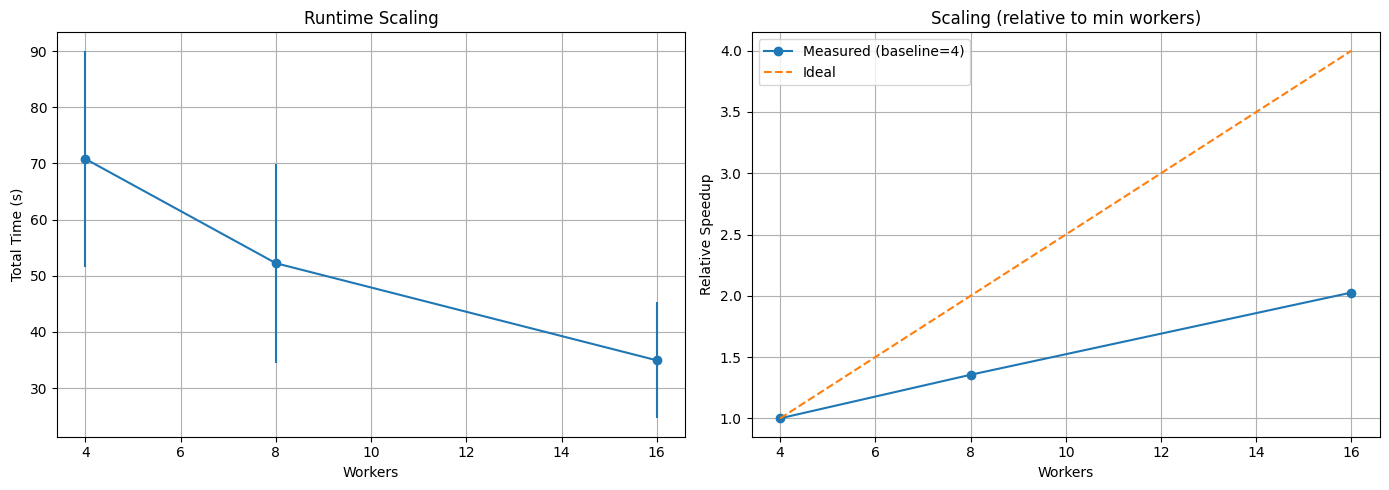

In [61]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Runtime with error bars ---
axs[0].errorbar(g["workers"], g["time_mean"], yerr=g["time_std"], marker="o")
axs[0].set_xlabel("Workers")
axs[0].set_ylabel("Total Time (s)")
axs[0].set_title("Runtime Scaling")
axs[0].grid(True)

# --- Speedup plot ---
w0 = g["workers"].min()
t0 = g.loc[g["workers"] == w0, "time_mean"].iloc[0]

g["speedup"] = t0 / g["time_mean"]

axs[1].plot(g["workers"], g["speedup"], marker="o", label=f"Measured (baseline={w0})")
axs[1].plot(g["workers"], g["workers"]/w0, "--", label="Ideal")
axs[1].set_xlabel("Workers")
axs[1].set_ylabel("Relative Speedup")
axs[1].set_title("Scaling (relative to min workers)")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


## Selecting the best architecture

We want now to find the best possible architecture between the one tested, we start to see if some performance are in the top for quality and time. Then we move on in implementing a method that allow us to compare different architecture ignoring the size of clustering

In [62]:

def best_by_inertia(df, top_n=5):
    """
    For each k, select the top N runs with lowest inertia_full.
    Keeps all hyperparameters and other columns.
    """
    df_valid = df[df["inertia_full"].notna()]
    
    best_perf_list = []
    
    for k_val, group in df_valid.groupby("k"):
        top_runs = group.nsmallest(top_n, "inertia_full")  # lowest inertia
        best_perf_list.append(top_runs)
    
    best_perf = pd.concat(best_perf_list).reset_index(drop=True)
    return best_perf


def best_by_time(df, top_n=5):
    """
    For each k, select the top N runs with fastest total_time.
    Keeps all hyperparameters and other columns.
    """
    df_valid = df[df["total_time"].notna()]
    
    best_time_list = []
    
    for k_val, group in df_valid.groupby("k"):
        top_runs = group.nsmallest(top_n, "total_time")  # fastest time
        best_time_list.append(top_runs)
    
    best_time = pd.concat(best_time_list).reset_index(drop=True)
    return best_time



In [63]:
best_perf = best_by_inertia(df_tot)
best_time = best_by_time(df_tot)

print("Best clustering quality per k")
print(best_perf.head())

print("\nFastest runs per k")
print(best_time.head())

Best clustering quality per k
   Unnamed: 0   k  blk      bs  r   l    mc  it  vms  workers  total_time  \
0         144  20   24  200000  5  10  5000  10    4        8       35.61   
1         246  20   16  200000  5  10  5000  10    4        8       32.31   
2          14  20   16  200000  5  40  5000   5    4        8       30.52   
3         112  20   24  200000  5  40  5000   5    4        8       33.90   
4          41  20   24  200000  5  40  5000  10    4        8       37.04   

   inertia_full  mean_dist  median_dist  max_dist  
0   391649700.0    130.893      52.0746   1565.08  
1   391649700.0    130.894      52.0944   1565.08  
2   391962500.0    175.707      68.2076   1961.74  
3   391962500.0    175.436      68.2076   1961.74  
4   392007900.0    174.547      68.2094   1961.69  

Fastest runs per k
   Unnamed: 0   k  blk      bs  r   l    mc  it  vms  workers  total_time  \
0         386  20   32  200000  5  20  5000  10    8       16       17.46   
1         363  20   6

In [64]:
best_perf.sort_values("inertia_full").head(10)

,Unnamed: 0,k,blk,bs,r,l,mc,it,vms,workers,total_time,inertia_full,mean_dist,median_dist,max_dist
20,280,100,64,200000,6,100,5000,10,4,4,82.64,90528060.0,99.2140,68.0988,989.929
21,344,100,64,200000,6,100,5000,10,8,8,50.65,90579840.0,99.1973,68.0988,989.929
22,278,100,32,200000,6,100,5000,10,4,4,82.98,90592410.0,98.2493,67.8845,989.884
23,342,100,32,200000,6,100,5000,10,8,8,49.39,90592410.0,98.2493,67.8845,989.884
24,259,100,32,200000,5,200,5000,10,4,4,87.82,91597590.0,97.5250,67.5412,989.856
15,460,75,32,200000,5,75,5000,20,8,16,53.69,164198400.0,124.8620,68.0664,2712.610
16,397,75,32,150000,5,75,5000,20,8,16,60.25,164683800.0,122.3200,68.0658,2712.340
17,458,75,32,100000,5,75,5000,20,8,16,53.46,164972300.0,121.0750,68.0661,2712.340
18,452,75,32,200000,5,75,5000,10,8,16,43.58,165350400.0,121.5050,67.9731,2712.610
19,463,75,32,150000,5,75,5000,10,8,16,44.57,166076900.0,118.7020,68.0991,2712.340


In [65]:
best_time.sort_values("total_time").head(10)

,Unnamed: 0,k,blk,bs,r,l,mc,it,vms,workers,total_time,inertia_full,mean_dist,median_dist,max_dist
0,386,20,32,200000,5,20,5000,10,8,16,17.46,406172700.0,61.3113,67.7965,240.640
1,363,20,64,200000,5,20,5000,5,8,8,21.93,406969000.0,59.1945,67.7570,207.753
2,440,20,32,150000,5,20,5000,10,8,16,22.14,405757100.0,61.4761,67.7930,245.253
3,382,20,32,100000,5,20,5000,10,8,16,22.31,401526600.0,63.4867,68.0742,229.847
4,374,20,32,200000,5,20,5000,5,8,8,22.65,406969000.0,59.0057,67.8054,207.852
10,434,50,32,100000,5,50,5000,10,8,16,22.93,270850300.0,60.5394,67.5989,204.645
5,466,35,32,50000,5,35,5000,10,8,16,23.17,334545300.0,69.1584,68.0478,347.142
6,399,35,32,100000,5,35,5000,10,8,16,23.24,334744200.0,69.3721,68.0470,294.158
11,444,50,32,200000,5,50,5000,10,8,16,23.71,273983500.0,83.2212,67.5906,989.889
15,406,75,32,50000,5,75,5000,10,8,16,24.07,187939400.0,62.7646,66.6539,409.550


In [66]:
#Let's see if some run compares in both:
# Columns that identify a run uniquely
hp_cols = ["k", "blk", "bs", "r", "l", "mc", "it"]

# Convert to sets of tuples for comparison
top_inertia_set = set([tuple(x) for x in best_perf[hp_cols].values])
top_time_set = set([tuple(x) for x in best_time[hp_cols].values])

# Intersection: runs that are in both top lists
common_runs = top_inertia_set.intersection(top_time_set)

# Convert back to DataFrame
common_df = best_perf[best_perf[hp_cols].apply(tuple, axis=1).isin(common_runs)]

print("Runs that are both fast and high quality:")
print(common_df)


Runs that are both fast and high quality:
    Unnamed: 0   k  blk      bs  r   l    mc  it  vms  workers  total_time  \
11         388  50   32  150000  5  50  5000  10    8       16       45.15   
13         453  50   32  100000  5  50  5000  10    8       16       41.80   
18         452  75   32  200000  5  75  5000  10    8       16       43.58   
19         463  75   32  150000  5  75  5000  10    8       16       44.57   

    inertia_full  mean_dist  median_dist  max_dist  
11   250269300.0    161.395      67.8811   2213.25  
13   251592800.0    183.348      67.8466   2712.59  
18   165350400.0    121.505      67.9731   2712.61  
19   166076900.0    118.702      68.0991   2712.34  


### A Method to select the best architecture

The goal of this phase is to identify the best-performing architecture while accounting for the inherent trade-off between clustering quality and execution time. Faster configurations may lead to higher inertia, while more accurate ones usually require more computation, so no single configuration can be considered strictly optimal. In addition, results are produced for multiple values of \(k\), and both inertia and runtime scale with the number of clusters. To enable fair comparison across different \(k\), inertia and total time are normalized within each \(k\) by dividing each value by the corresponding group mean.

After normalization, configurations are aggregated at the architecture level, where an architecture is defined by the tuple \((blk, cr, bs, r, l, mc, it, workers)\). For each unique architecture, we compute the mean normalized inertia and the mean normalized execution time across all runs and values of \(k\). This produces a global characterization of each architecture independent of the cluster size.

Since inertia and time represent competing objectives, we adopt a Pareto-style ranking rather than selecting a single optimum. Architectures are ranked separately according to normalized inertia and normalized time, and a weighted score is built by giving more importance to inertia than runtime. The final score combines these ranks, allowing us to compare architectures while prioritizing clustering quality and reducing the bias introduced by different values of \(k\). The best architectures are those with the lowest combined score.


In [67]:
# --- define architecture columns ---
arch_cols = ["blk","bs","r","l","mc","it","workers"]
w_in = 2
w_t = 1
# --- normalize metrics inside each k ---
df["inertia_norm"] = df.groupby("k")["inertia_full"].transform(
    lambda x: x / x.mean()
)

df["time_norm"] = df.groupby("k")["total_time"].transform(
    lambda x: x / x.mean()
)

# --- aggregate per architecture ---
arch_scaled = df.groupby(arch_cols).agg(
    inertia_norm_mean=("inertia_norm","mean"),
    time_norm_mean=("time_norm","mean"),
    runs=("k","count")
).reset_index()

# --- rank-based score (no std needed) ---
arch_scaled["inertia_rank"] = arch_scaled["inertia_norm_mean"].rank(method="min")
arch_scaled["time_rank"] = arch_scaled["time_norm_mean"].rank(method="min")

arch_scaled["score_rank"] = (
    w_in * arch_scaled["inertia_rank"] +
    w_t * arch_scaled["time_rank"]
)

arch_scaled["score_avg"] = (
    w_in * arch_scaled["inertia_norm_mean"] +
    w_t * arch_scaled["time_norm_mean"]
)

# --- show best architectures ---
arch_scaled_sorted_r = arch_scaled.sort_values("score_rank")
print(arch_scaled_sorted_r.head(10))

     blk      bs  r    l    mc  it  workers  inertia_norm_mean  \
92    24  200000  5   10  5000   5        8           0.966531   
96    24  200000  5   40  5000   5        8           0.963126   
58    16  200000  5   10  5000   5        8           0.979948   
93    24  200000  5   10  5000  10        8           0.962357   
124   32  150000  5   50  5000  10       16           0.966071   
126   32  150000  5   75  5000  10       16           0.973778   
97    24  200000  5   40  5000  10        8           0.963237   
215   64  200000  5  150  5000  10        8           0.959528   
159   32  200000  5  150  5000  10        8           0.959528   
125   32  150000  5   50  5000  20       16           0.962902   

     time_norm_mean  runs  inertia_rank  time_rank  score_rank  score_avg  
92         0.593847     1          19.0       17.0        55.0   2.526910  
96         0.717442     1          14.0       61.0        89.0   2.643693  
58         0.556811     2          44.0      

In [68]:
df = df[df["l"] == df["k"]]
df.drop(columns =['l'])
# --- define architecture columns ---
arch_cols = ["blk","bs","r","mc","it","workers"]
w_in = 2
w_t = 1
# --- normalize metrics inside each k ---
df["inertia_norm"] = df.groupby("k")["inertia_full"].transform(
    lambda x: x / x.mean()
)

df["time_norm"] = df.groupby("k")["total_time"].transform(
    lambda x: x / x.mean()
)

# --- aggregate per architecture ---
arch_scaled = df.groupby(arch_cols).agg(
    inertia_norm_mean=("inertia_norm","mean"),
    time_norm_mean=("time_norm","mean"),
    runs=("k","count")
).reset_index()

# --- rank-based score (no std needed) ---
arch_scaled["inertia_rank"] = arch_scaled["inertia_norm_mean"].rank(method="min")
arch_scaled["time_rank"] = arch_scaled["time_norm_mean"].rank(method="min")

arch_scaled["score_rank"] = (
    w_in * arch_scaled["inertia_rank"] +
    w_t * arch_scaled["time_rank"]
)

arch_scaled["score_avg"] = (
    w_in * arch_scaled["inertia_norm_mean"] +
    w_t * arch_scaled["time_norm_mean"]
)

# --- show best architectures ---
arch_scaled_sorted_r = arch_scaled.sort_values("score_rank")
print(arch_scaled_sorted_r.head(10))

    blk      bs  r    mc  it  workers  inertia_norm_mean  time_norm_mean  \
46   32  150000  5  5000  10       16           0.982262        0.693344   
12   16  100000  5  5000   5        8           0.988365        0.553185   
35   24  100000  5  5000  10        8           0.986632        0.676602   
38   24  200000  5  5000   5        8           0.987919        0.618547   
52   32  200000  5  5000  10       16           0.987408        0.657803   
34   24  100000  5  5000   5        8           0.988366        0.591759   
47   32  150000  5  5000  20       16           0.976657        0.820518   
39   24  200000  5  5000  10        8           0.987358        0.711085   
53   32  200000  5  5000  20       16           0.982596        0.824885   
26   16  200000  5  5000   5        8           0.993669        0.576563   

    runs  inertia_rank  time_rank  score_rank  score_avg  
46    11           2.0       12.0        16.0   2.657869  
12     2           8.0        1.0        17.0

In [69]:
#Let's see the score for the best run in inertia
sorted_inertia = arch_scaled.sort_values("inertia_rank")
sorted_inertia.head(1)

,blk,bs,r,mc,it,workers,inertia_norm_mean,time_norm_mean,runs,inertia_rank,time_rank,score_rank,score_avg
47,32,150000,5,5000,20,16,0.976657,0.820518,12,1.0,21.0,23.0,2.773832


In [70]:
#Let's see the score for the best run in time
sorted_time = arch_scaled.sort_values("time_rank")
sorted_time.head(1)

,blk,bs,r,mc,it,workers,inertia_norm_mean,time_norm_mean,runs,inertia_rank,time_rank,score_rank,score_avg
12,16,100000,5,5000,5,8,0.988365,0.553185,2,8.0,1.0,17.0,2.529916


In [71]:
# We're using this combination of parameters as the "best" but we're going back at it in a while before let's do some plot that help us to have an ideo ù
best_run = arch_scaled_sorted_r.head(1)
best_run

,blk,bs,r,mc,it,workers,inertia_norm_mean,time_norm_mean,runs,inertia_rank,time_rank,score_rank,score_avg
46,32,150000,5,5000,10,16,0.982262,0.693344,11,2.0,12.0,16.0,2.657869


Considering a weight for the inertia as double of the one for time we have obtained the previous set of parameter as "best" as said before doesn't exist a absolute optimum but only a pareto one. We essentially decide which and how much the target performance are important tous. anyway the model selected overperform the average in bot time and inertia across the different runs.

## Correlation

We analyze how different parameters correlate with the target performance using **Spearman’s rank correlation**, which measures **monotonic relationships** between variables.

Spearman correlation is computed as:


$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$

where $ d_i $ is the difference between the ranks of paired observations and $ n $ is the number of samples.

This helps us understand how each parameter influences performance, even when relationships are non-linear. we still use the scaled dataset to be able to evaluate the correlation across different architectures.


In [72]:
import pandas as pd

features = ["blk", "bs", "r", "it", "workers"]
targets = ["time_norm_mean", "inertia_norm_mean"]

corr = arch_scaled[features + targets].corr(method="spearman")

corr_targets = corr.loc[features, targets]
corr_targets


,time_norm_mean,inertia_norm_mean
blk,-0.283835,0.191934
bs,-0.060987,0.004199
r,0.681859,0.254717
it,0.411574,-0.383476
workers,-0.508833,-0.460449


### Benchmarking

We now compare the obtained results with a benchmark.  
We use **inertia** as the target metric and, for each value of \(k\), select the architecture that achieved the best inertia.

These best results are then compared against the inertia obtained from a **standard locally computed `sklearn` KMeans** model.  

This allows us to evaluate how our approach performs relative to a well-established baseline implementation.


In [73]:
#lets first select the best run for each k
# Import the dataset
df_tot = pd.read_csv("dataframez/Runs_outputs_total_final.csv")
df_tot = df_tot.drop(columns=["folder"])


In [74]:
# Let's select the best run in term of quality for each k
df_best = df_tot.loc[df_tot.groupby('k')['inertia_full'].idxmin()]
df_best = df_best.reset_index(drop=True)
df_best.head(10)

,Unnamed: 0,k,blk,cr,bs,r,l,mc,it,vms,workers,centroids,total_time,inertia_full,mean_dist,median_dist,max_dist
0,144,20,24,50000,200000,5,10,5000,10,4,8,[[-6.6751242e-02 -9.7761978e-04 -1.6918555e-03...,35.61,391649700.0,130.8930,52.0746,1565.080
1,84,35,16,100000,100000,6,35,5000,20,4,8,[[-6.5207131e-02 -9.6452911e-04 -1.6932401e-03...,57.18,316682700.0,76.1079,68.0976,418.538
2,427,50,32,20000,150000,5,50,5000,20,8,16,[[-6.6833176e-02 -1.0322600e-03 -1.6955070e-03...,51.91,249444800.0,167.1020,67.9561,2213.250
3,460,75,32,20000,200000,5,75,5000,20,8,16,[[-6.6665575e-02 -1.0503331e-03 -1.6796575e-03...,53.69,164198400.0,124.8620,68.0664,2712.610
4,280,100,64,100000,200000,6,100,5000,10,4,4,[[-6.6833161e-02 -9.8411273e-04 -1.6955066e-03...,82.64,90528060.0,99.2140,68.0988,989.929


In [75]:
#let's load the reference dataframe
ref_df= pd.read_csv("dataframez/ref_df.csv")
ref_df.head()

,Unnamed: 0,k,centroids,inertia,time
0,0,20,[[-6.6599108e-02 -9.8078640e-04 -1.6854153e-03...,381641728.0,25.129896
1,1,35,[[-6.6598907e-02 -9.8224310e-04 -1.6854142e-03...,307060736.0,39.860150
2,2,50,[[-6.6598900e-02 -9.8224264e-04 -1.6854141e-03...,233824624.0,57.900685
3,3,75,[[-6.6639125e-02 -9.5819315e-04 -1.6895650e-03...,112471864.0,91.135813
4,4,100,[[-6.66391253e-02 -9.58169403e-04 -1.68956525e...,26598974.0,134.688553


In [76]:
df_best

,Unnamed: 0,k,blk,cr,bs,r,l,mc,it,vms,workers,centroids,total_time,inertia_full,mean_dist,median_dist,max_dist
0,144,20,24,50000,200000,5,10,5000,10,4,8,[[-6.6751242e-02 -9.7761978e-04 -1.6918555e-03...,35.61,391649700.0,130.8930,52.0746,1565.080
1,84,35,16,100000,100000,6,35,5000,20,4,8,[[-6.5207131e-02 -9.6452911e-04 -1.6932401e-03...,57.18,316682700.0,76.1079,68.0976,418.538
2,427,50,32,20000,150000,5,50,5000,20,8,16,[[-6.6833176e-02 -1.0322600e-03 -1.6955070e-03...,51.91,249444800.0,167.1020,67.9561,2213.250
3,460,75,32,20000,200000,5,75,5000,20,8,16,[[-6.6665575e-02 -1.0503331e-03 -1.6796575e-03...,53.69,164198400.0,124.8620,68.0664,2712.610
4,280,100,64,100000,200000,6,100,5000,10,4,4,[[-6.6833161e-02 -9.8411273e-04 -1.6955066e-03...,82.64,90528060.0,99.2140,68.0988,989.929


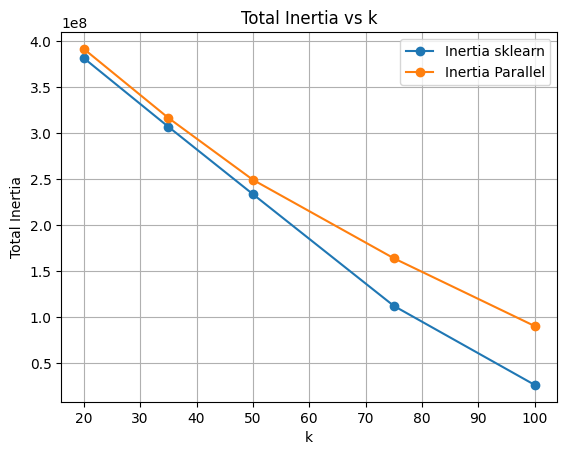

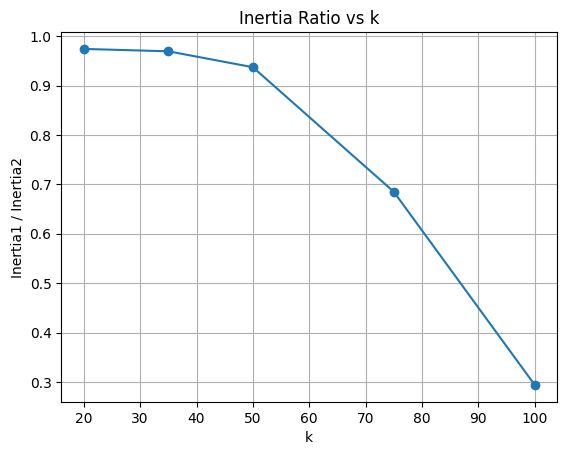

In [77]:
#Let's plot the inertia over different k

plt.figure()
plt.plot(ref_df["k"], ref_df["inertia"], marker="o", label="Inertia sklearn")
plt.plot(df_best["k"], df_best["inertia_full"], marker="o", label="Inertia Parallel")

plt.xlabel("k")
plt.ylabel("Total Inertia")
plt.title("Total Inertia vs k")
plt.legend()
plt.grid(True)

plt.show()

merged = df_best.merge(ref_df, on="k")

merged["inertia_ratio"] = merged["inertia"] / merged["inertia_full"]

plt.figure()
plt.plot(merged["k"], merged["inertia_ratio"], marker="o")

plt.xlabel("k")
plt.ylabel("Inertia1 / Inertia2")
plt.title("Inertia Ratio vs k")
plt.grid(True)

plt.show()



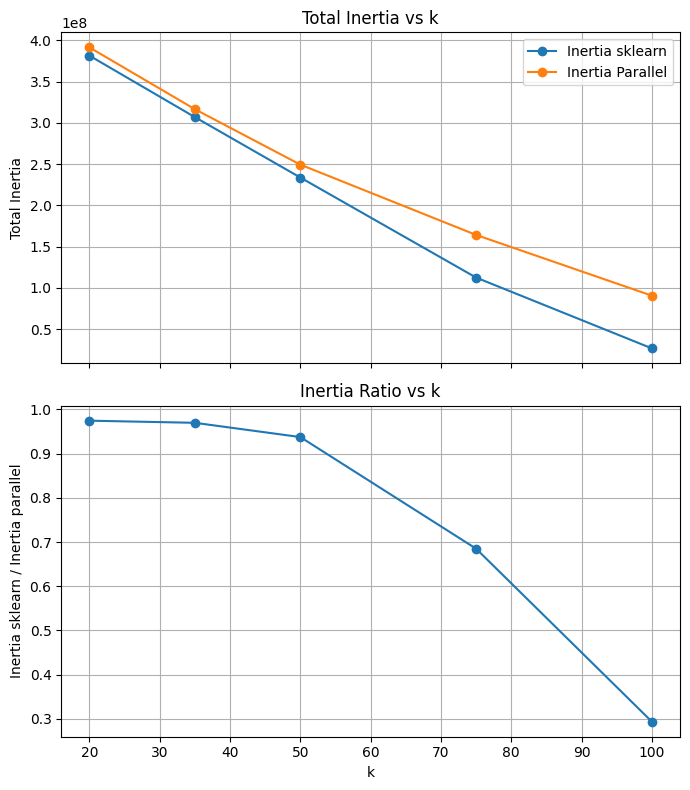

In [78]:
fig, axs = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

# --- First plot: Inertia vs k ---
axs[0].plot(ref_df["k"], ref_df["inertia"], marker="o", label="Inertia sklearn")
axs[0].plot(df_best["k"], df_best["inertia_full"], marker="o", label="Inertia Parallel")
axs[0].set_ylabel("Total Inertia")
axs[0].set_title("Total Inertia vs k")
axs[0].legend()
axs[0].grid(True)

# --- Merge and compute ratio ---
merged = df_best.merge(ref_df, on="k")
merged["inertia_ratio"] = merged["inertia"] / merged["inertia_full"]

# --- Second plot: Ratio ---
axs[1].plot(merged["k"], merged["inertia_ratio"], marker="o")
axs[1].set_xlabel("k")
axs[1].set_ylabel("Inertia sklearn / Inertia parallel")
axs[1].set_title("Inertia Ratio vs k")
axs[1].grid(True)

plt.tight_layout()
plt.show()


Our algorithm, especially since it is a **MiniBatch** version, does not outperform the standard `sklearn` implementation. This behavior is expected because MiniBatch K-Means is an **approximation of Lloyd’s algorithm**, trading accuracy for speed and scalability.

We can also observe that as the number of clusters increases, the performance gap becomes larger. This happens because with higher \(k\), the approximation introduced by mini-batches accumulates more error, making it harder to precisely adjust all centroids using only small subsets of the data at each iteration.


# Analysis of the inertia as a function of K

Loading the datasets for the two architectures, we extract the files relative to the full dataset inertia. 

We select the last iteration, average over the samples and plot the final inertia for different values of k. Also shown in different colours are the different oversampling factors. 

This analysis is focused on showing how the cluster size affects the performance of the algorithm and how the initialization in parallel helps to overcome these issues. In particular, for the random initialization, the inertia is much larger than the parallel initialization case.

We can also see how the inertia for the parallel inizialitation diminshes much faster as the number of clusters increases, compared to the random init.

For the larger architecture of 16 workers over 8 VM, we were also able to get some data for larger clusters, and can see how after k=100, the final inertia starts to saturate. To keep performances stable, we decided to keep k=100 as our larger cluster size.

# 4VM - 8 Workers

Load the data from the appropriate folder, collect the information for the inertia

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# =================
# 1. CONFIGURATION
# =================
RESULTS_FOLDER = "/MAPD_project/kdd_results_different_init_4VM_8workers_new"
print(f"Scanning {RESULTS_FOLDER}...")

filename_pattern = re.compile(
    r"minibatch_final_inertia_(kmeans\|\||random)_l_([\d\.]+)_k_(\d+)_it_(\d+)_(\d+)\.txt"
)

rows = []

if not os.path.exists(RESULTS_FOLDER):
    raise FileNotFoundError(f"CRITICAL: Folder not found: {RESULTS_FOLDER}")


Scanning /MAPD_project/kdd_results_different_init_4VM_8workers_new...


In [80]:
for fn in os.listdir(RESULTS_FOLDER):
    m = filename_pattern.search(fn)
    if not m:
        continue

    init = m.group(1) # "kmeans||" or "random"
    l_val = float(m.group(2))
    k_val = int(m.group(3))
    it = int(m.group(4))
    rep = int(m.group(5))

    path = os.path.join(RESULTS_FOLDER, fn)

    with open(path, "r") as f:
        content = f.read().strip()
    clean = content.replace("[", "").replace("]", "").replace(",", " ").replace("\n", " ")
    vals = [float(x) for x in clean.split() if x]

    if not vals:
        continue

    inertia = vals[-1] 
    rows.append({"init": init, "l": l_val, "k": k_val, "it": it, "rep": rep, "inertia": inertia})

Create the dataframe, keep the last iteration to compute the last inertia. Aggregate by init to distinguish between || and random and by k and l for analysis.

In [81]:
df = pd.DataFrame(rows)
print(f"-> Found {len(df)} inertia points.")
display(df.head())

USE_LAST_IT_PER_RUN = True

if USE_LAST_IT_PER_RUN:
    # Keep only the max it for each (init,l,k,rep)
    df_use = (
        df.sort_values(["init", "l", "k", "rep", "it"])
          .groupby(["init", "l", "k", "rep"], as_index=False)
          .tail(1)
          .reset_index(drop=True)
    )
    print(f"-> Using last it per run: {len(df_use)} points.")
else:
    df_use = df.copy()
    print(f"-> Using all its: {len(df_use)} points.")

# ==========================================
# Aggregate inertia by (init, l, k)
# ==========================================
agg = (
    df_use.groupby(["init", "l", "k"])
          .agg(inertia_mean=("inertia", "mean"),
               inertia_std=("inertia", "std"),
               n=("inertia", "count"))
          .reset_index()
          .sort_values(["init", "l", "k"])
)

display(agg.head(20))

-> Found 486 inertia points.


,init,l,k,it,rep,inertia
0,kmeans||,20.0,20,7,0,395031488.0
1,kmeans||,150.0,100,6,1,58824888.0
2,kmeans||,50.0,50,1,0,256782144.0
3,kmeans||,100.0,100,4,0,61436520.0
4,random,100.0,100,4,2,369789088.0


-> Using last it per run: 54 points.


,init,l,k,inertia_mean,inertia_std,n
0,kmeans||,10.0,20,3.916497e+08,0.000000,3
1,kmeans||,20.0,20,3.950236e+08,0.000000,3
2,kmeans||,25.0,50,2.528838e+08,0.000000,3
3,kmeans||,30.0,20,3.974118e+08,18.475209,3
4,kmeans||,50.0,50,2.512810e+08,0.000000,3
5,kmeans||,50.0,100,4.825822e+07,0.000000,3
6,kmeans||,75.0,50,2.415631e+08,9.237604,3
7,kmeans||,100.0,100,6.132635e+07,4.618802,3
8,kmeans||,150.0,100,5.875206e+07,2.309401,3
9,random,10.0,20,4.522035e+08,0.000000,3


In [82]:
#df.to_csv(f'Inertia_for_k_raw.csv')

In [83]:
INIT_MAIN = "kmeans||"
INIT_BASELINE = "random"

# --- split ---
df_ll = agg[agg["init"] == INIT_MAIN].copy()
df_rand = agg[agg["init"] == INIT_BASELINE].copy()

if df_ll.empty:
    raise RuntimeError("No data found for init=kmeans||")
if df_rand.empty:
    raise RuntimeError("No data found for init=random")

# multiplicative factor
df_ll["factor"] = (df_ll["l"] / df_ll["k"]).round(6)

In [84]:
# Compute mean and std 
def combine_mean_std(df, group_cols, mean_col="inertia_mean", std_col="inertia_std", n_col="n"):
    d = df.copy()
    d[n_col] = d[n_col].fillna(1).astype(float)
    d[std_col] = d[std_col].fillna(0.0).astype(float)
    d[mean_col] = d[mean_col].astype(float)

    # weighted mean
    def _agg(g):
        n = g[n_col].to_numpy()
        mu = g[mean_col].to_numpy()
        sd = g[std_col].to_numpy()

        N = n.sum()
        if N <= 0:
            return pd.Series({"mean": np.nan, "std": np.nan, "N": 0})

        mean = (n * mu).sum() / N

        # pooled variance (population form): E[var] + Var[E]
        # var_total = sum_i (n_i*(sd_i^2 + (mu_i-mean)^2)) / N
        var = (n * (sd**2 + (mu - mean)**2)).sum() / N
        std = np.sqrt(var)

        return pd.Series({"mean": mean, "std": std, "N": N})

    out = (
        d.groupby(group_cols, as_index=False)
         .apply(_agg, include_groups=False)
    )
    # groupby.apply gives group cols in index in some pandas versions; normalize:
    if isinstance(out.index, pd.MultiIndex):
        out = out.reset_index()
    # ensure columns
    cols = list(group_cols) + ["mean", "std", "N"]
    out = out[cols]
    return out

Plot the final inertia for different values of k. Overlay different values of l to see if the performance changes.

Keep the random case as a baseline. 

Overlayed multiplicative factors (l/k): [np.float64(0.5), np.float64(1.0), np.float64(1.5)]


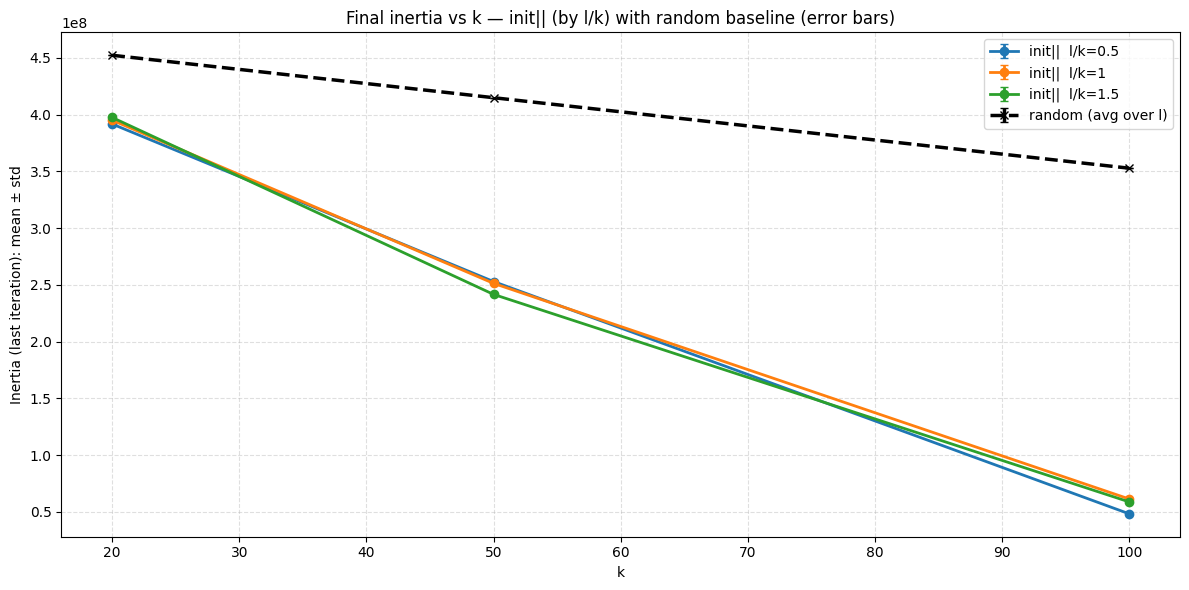

In [85]:
# init||: aggregate per (multiplicative factor, k)
plot_ll = combine_mean_std(df_ll, group_cols=["factor", "k"])

# random: aggregate per k across all l (they're irrelevant)
plot_rand = combine_mean_std(df_rand, group_cols=["k"])

plot_ll = plot_ll.sort_values(["factor", "k"])
plot_rand = plot_rand.sort_values(["k"])

factors = sorted(plot_ll["factor"].unique())
print("Overlayed multiplicative factors (l/k):", factors)

# ============================
# Plot with error bars
# ============================
plt.figure(figsize=(12, 6))

# init|| curves
for f in factors:
    s = plot_ll[plot_ll["factor"] == f].sort_values("k")
    plt.errorbar(
        s["k"], s["mean"], yerr=s["std"],
        fmt="o-", capsize=3, linewidth=2,
        label=f"init||  l/k={f:g}"
    )

# random baseline (black)
plt.errorbar(
    plot_rand["k"], plot_rand["mean"], yerr=plot_rand["std"],
    fmt="x--", capsize=3, linewidth=2.5, color="black",
    label="random (avg over l)"
)

plt.xlabel("k")
plt.ylabel("Inertia (last iteration): mean ± std")
plt.title("Final inertia vs k — init|| (by l/k) with random baseline (error bars)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


# 8VM - 16 Workers

Same as before, but now we were able to extend the range for the number of clusters, identifying a plateau.

In [86]:
# ==============
# CONFIGURATION
# ==============
RESULTS_FOLDER = "/MAPD_project/kdd_results_different_init_8VM_16workers_new"
print(f"Scanning {RESULTS_FOLDER}...")

filename_pattern = re.compile(
    r"minibatch_final_inertia_(kmeans\|\||random)_l_([\d\.]+)_k_(\d+)_it_(\d+)_(\d+)\.txt"
)

rows = []

if not os.path.exists(RESULTS_FOLDER):
    raise FileNotFoundError(f"CRITICAL: Folder not found: {RESULTS_FOLDER}")

Scanning /MAPD_project/kdd_results_different_init_8VM_16workers_new...


In [87]:
for fn in os.listdir(RESULTS_FOLDER):
    m = filename_pattern.search(fn)
    if not m:
        continue

    init = m.group(1) # "kmeans||" or "random"
    l_val = float(m.group(2))
    k_val = int(m.group(3))
    it = int(m.group(4))
    rep = int(m.group(5))

    path = os.path.join(RESULTS_FOLDER, fn)

    with open(path, "r") as f:
        content = f.read().strip()
    clean = content.replace("[", "").replace("]", "").replace(",", " ").replace("\n", " ")
    vals = [float(x) for x in clean.split() if x]

    if not vals:
        continue

    inertia = vals[-1] 
    rows.append({"init": init, "l": l_val, "k": k_val, "it": it, "rep": rep, "inertia": inertia})

In [88]:
df = pd.DataFrame(rows)
print(f"-> Found {len(df)} inertia points.")
display(df.head())

# Consider only the last iteration fo inertia
USE_LAST_IT_PER_RUN = True

if USE_LAST_IT_PER_RUN:
    # Keep only the max it for each (init,l,k,rep)
    df_use = (
        df.sort_values(["init", "l", "k", "rep", "it"])
          .groupby(["init", "l", "k", "rep"], as_index=False)
          .tail(1)
          .reset_index(drop=True)
    )
    print(f"-> Using last it per run: {len(df_use)} points.")
else:
    df_use = df.copy()
    print(f"-> Using all its: {len(df_use)} points.")

# ==========================================
# Aggregate inertia by (init, l, k)
# ==========================================
agg = (
    df_use.groupby(["init", "l", "k"])
          .agg(inertia_mean=("inertia", "mean"),
               inertia_std=("inertia", "std"),
               n=("inertia", "count"))
          .reset_index()
          .sort_values(["init", "l", "k"])
)

display(agg.head(20))

-> Found 1016 inertia points.


,init,l,k,it,rep,inertia
0,kmeans||,100.0,100,7,99,62587648.0
1,kmeans||,75.0,150,1,7,13082368.0
2,kmeans||,20.0,20,7,0,394557056.0
3,kmeans||,150.0,100,6,1,61306452.0
4,kmeans||,50.0,50,1,0,251242592.0


-> Using last it per run: 104 points.


,init,l,k,inertia_mean,inertia_std,n
0,kmeans||,10.0,20,3.872307e+08,0.000000e+00,3
1,kmeans||,20.0,20,3.941545e+08,3.420800e+05,4
2,kmeans||,25.0,50,2.446660e+08,0.000000e+00,3
3,kmeans||,30.0,20,4.135168e+08,0.000000e+00,3
4,kmeans||,50.0,50,2.490570e+08,1.215200e+05,4
5,kmeans||,50.0,100,4.241687e+07,0.000000e+00,3
6,kmeans||,75.0,50,2.549067e+08,0.000000e+00,3
7,kmeans||,75.0,150,1.331009e+07,1.074968e+00,10
8,kmeans||,100.0,100,6.170701e+07,4.838820e+05,4
9,kmeans||,100.0,200,7.631726e+06,NaN,1


In [89]:
INIT_MAIN = "kmeans||"
INIT_BASELINE = "random"

# --- split ---
df_ll = agg[agg["init"] == INIT_MAIN].copy()
df_rand = agg[agg["init"] == INIT_BASELINE].copy()

if df_ll.empty:
    raise RuntimeError("No data found for init=kmeans||")
if df_rand.empty:
    raise RuntimeError("No data found for init=random")

# multiplicative factor
df_ll["factor"] = (df_ll["l"] / df_ll["k"]).round(6)

In [90]:
def combine_mean_std(df, group_cols, mean_col="inertia_mean", std_col="inertia_std", n_col="n"):
    d = df.copy()
    d[n_col] = d[n_col].fillna(1).astype(float)
    d[std_col] = d[std_col].fillna(0.0).astype(float)
    d[mean_col] = d[mean_col].astype(float)

    # weighted mean
    def _agg(g):
        n = g[n_col].to_numpy()
        mu = g[mean_col].to_numpy()
        sd = g[std_col].to_numpy()

        N = n.sum()
        if N <= 0:
            return pd.Series({"mean": np.nan, "std": np.nan, "N": 0})

        mean = (n * mu).sum() / N

        # pooled variance (population form): E[var] + Var[E]
        # var_total = sum_i (n_i*(sd_i^2 + (mu_i-mean)^2)) / N
        var = (n * (sd**2 + (mu - mean)**2)).sum() / N
        std = np.sqrt(var)

        return pd.Series({"mean": mean, "std": std, "N": N})

    out = (
        d.groupby(group_cols, as_index=False)
         .apply(_agg, include_groups=False)
    )
    # groupby.apply gives group cols in index in some pandas versions; normalize:
    if isinstance(out.index, pd.MultiIndex):
        out = out.reset_index()
    # ensure columns
    cols = list(group_cols) + ["mean", "std", "N"]
    out = out[cols]
    return out
        

Overlayed multiplicative factors (l/k): [np.float64(0.5), np.float64(1.0), np.float64(1.5)]


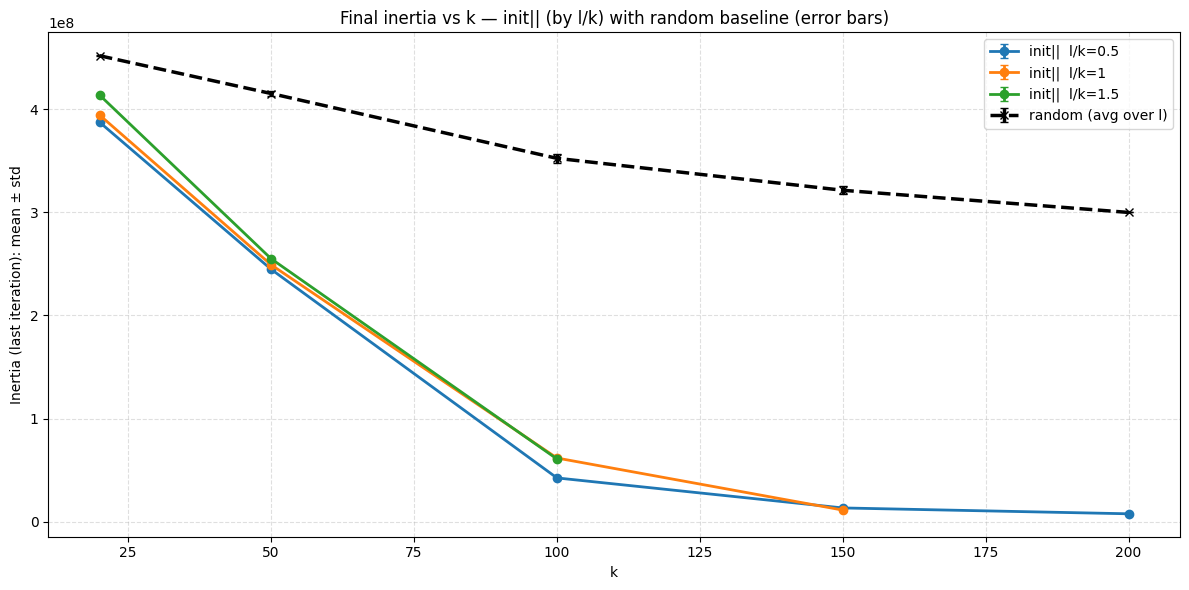

In [91]:
# init||: aggregate per (multiplicative factor, k)
plot_ll = combine_mean_std(df_ll, group_cols=["factor", "k"])

# random: aggregate per k across all l (they're irrelevant)
plot_rand = combine_mean_std(df_rand, group_cols=["k"])

plot_ll = plot_ll.sort_values(["factor", "k"])
plot_rand = plot_rand.sort_values(["k"])

factors = sorted(plot_ll["factor"].unique())
print("Overlayed multiplicative factors (l/k):", factors)

# ============================
# Plot with error bars
# ============================
plt.figure(figsize=(12, 6))

# init|| curves: one per factor
for f in factors:
    s = plot_ll[plot_ll["factor"] == f].sort_values("k")
    plt.errorbar(
        s["k"], s["mean"], yerr=s["std"],
        fmt="o-", capsize=3, linewidth=2,
        label=f"init||  l/k={f:g}"
    )

# random baseline (black)
plt.errorbar(
    plot_rand["k"], plot_rand["mean"], yerr=plot_rand["std"],
    fmt="x--", capsize=3, linewidth=2.5, color="black",
    label="random (avg over l)"
)

plt.xlabel("k")
plt.ylabel("Inertia (last iteration): mean ± std")
plt.title("Final inertia vs k — init|| (by l/k) with random baseline (error bars)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [92]:
df.head(5)


# Drop accidental index column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Average over repetitions per iteration
avg_iter = (
    df
    .groupby(["init", "l", "k", "it"], as_index=False)
    .agg(inertia_mean=("inertia", "mean"))
)

# Build curves safely
curves = (
    avg_iter
    .sort_values("it")
    .groupby(["init", "l", "k"], as_index=False)
    .apply(lambda g: pd.Series({
        "inertia_v": g["inertia_mean"].to_numpy(),
        "inertia_final": g["inertia_mean"].iloc[-1]
    }))
)

a = curves.iloc[:]['inertia_v']

#we got different iterations length in this dataframe, we select the ones that have len = 20
curves["inertia_len"] = curves["inertia_v"].apply(len)
curves_19 = curves[curves["inertia_len"] == 19]
curves_19.head(10)


/tmp/ipykernel_8317/3319587775.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,init,l,k,inertia_v,inertia_final,inertia_len
1,kmeans||,20.0,20,"[395412000.0, 395035520.0, 395018952.0, 395007...",393641408.0,19
4,kmeans||,50.0,50,"[251242592.0, 250451252.0, 250038240.0, 249839...",248874704.0,19
8,kmeans||,100.0,100,"[64576331.0, 64021798.0, 64009605.0, 63847411....",60981188.0,19
11,kmeans||,150.0,150,"[11472194.545454545, 11549900.545454545, 11515...",11158335.0,19
13,random,20.0,20,"[458565728.0, 456238720.0, 454951968.0, 454109...",450454688.0,19
16,random,50.0,50,"[437500576.0, 433449120.0, 430576448.0, 427002...",407822656.0,19
20,random,100.0,100,"[400328296.0, 386658504.0, 377213848.0, 370446...",339900512.0,19
23,random,150.0,150,"[380344712.72727275, 362281021.09090906, 35125...",304990560.0,19


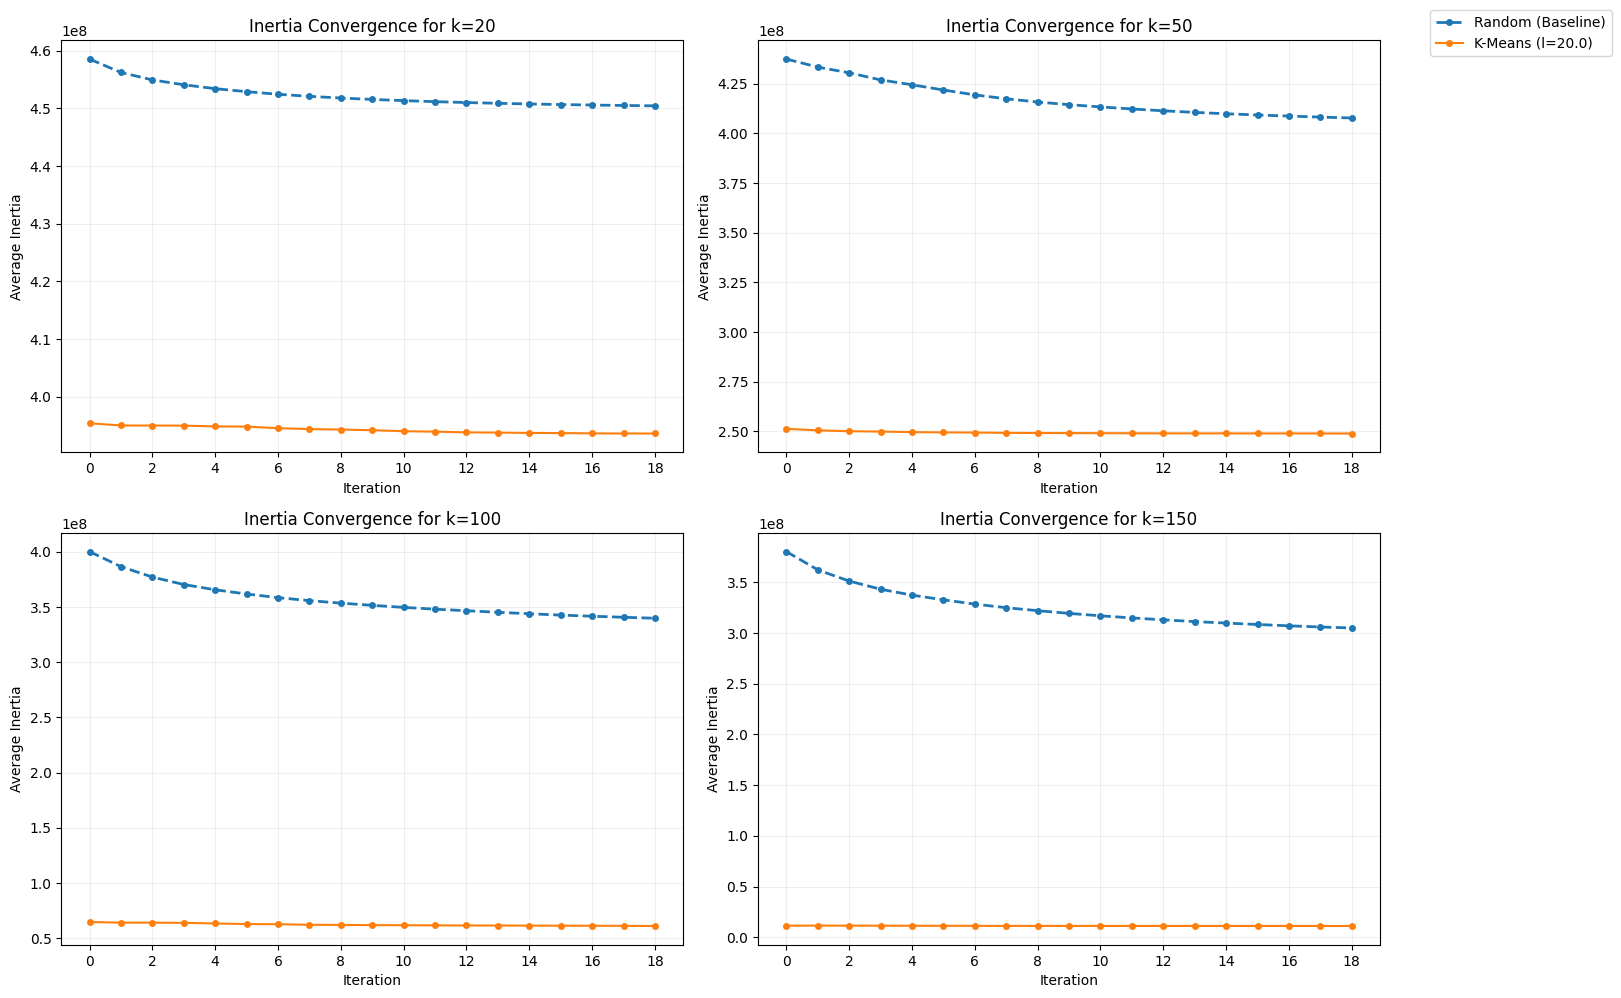

In [93]:
from matplotlib.ticker import MaxNLocator

unique_ks = sorted(curves_19["k"].unique())
n_ks = len(unique_ks)

cols = 2
rows = math.ceil(n_ks / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for idx, k_val in enumerate(unique_ks):
    ax = axes[idx]

    df_k = curves_19[curves_19["k"] == k_val]

    # --- Random baseline ---
    random_data = df_k[df_k["init"].str.contains("random", case=False)]
    if not random_data.empty:
        random_inertia = random_data.iloc[0]["inertia_v"]
        ax.plot(random_inertia, label="Random (Baseline)",
                linestyle="--", linewidth=2, marker="o", markersize=4)

    # --- KMeans curves ---
    kmeans_data = df_k[df_k["init"].str.contains("kmeans", case=False)]
    unique_ls = sorted(kmeans_data["l"].unique())

    for l_val in unique_ls:
        l_subset = kmeans_data[kmeans_data["l"] == l_val]
        if not l_subset.empty:
            inertia_curve = l_subset.iloc[0]["inertia_v"]
            ax.plot(inertia_curve, label=f"K-Means (l={l_val})",
                    marker="o", markersize=4)

    ax.set_title(f"Inertia Convergence for k={k_val}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Average Inertia")
    ax.grid(True, which="both", ls="-", alpha=0.2)

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Remove unused axes
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


These plots show the main difference between the two initialization. It is clear how the init|| gives a huge advantage to the kmeans algorithm, where the inertia at the first iteration is already very small, thus indicating that points have been properly assigned to their clusters.

Instead, for the random initialization, there is a quicker drop for the inertia on the first few iterations, but then it slows down and doesn't get close to the full init|| + k-means inertia.

# Analysis of the oversampling factor

In this notebook, we analyse the performance of the initializzation algorithm for different values of the oversampling factor.

In particular, we study how the initialization potential phi and the initialization time scale with the oversampling factor l.

## 8VM - 16 workers

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# --- CONFIGURATION ---
RESULTS_FOLDER = "/MAPD_project/kdd_results_different_init_8VM_16workers"
OUTPUT_PLOT = "oversampling_per_k.png"

# --- DATA PARSING ---
print(f"Scanning {RESULTS_FOLDER}...")

data_rows = []

# Captures: 1=metric, 2=l, 3=k, 4=rounds, 5=rep_idx
filename_pattern = re.compile(r'init_(phi|time)_l_([\d\.]+)_k_(\d+)_rounds_(\d+)_(\d+)\.txt')

Scanning /MAPD_project/kdd_results_different_init_8VM_16workers...


Parse filenames to extract the oversampling factor l and the associated run metadata needed for grouping and comparison.


In [95]:
if os.path.exists(RESULTS_FOLDER):
    files = os.listdir(RESULTS_FOLDER)
    
    for filename in files:
        match = filename_pattern.search(filename)
        if match:
            try:
                metric_type = match.group(1) # 'phi' or 'time'
                l_val = float(match.group(2))
                k_val = int(match.group(3))
                r_val = int(match.group(4))
                rep_idx = int(match.group(5))
                
                filepath = os.path.join(RESULTS_FOLDER, filename)
                with open(filepath, 'r') as f:
                    content = f.read().strip()
                    # Clean brackets if present (e.g. "[100, 50, 10]")
                    clean_content = content.replace('[', '').replace(']', '').replace(',', ' ').replace('\n', ' ')
                    values = [float(x) for x in clean_content.split()]
                    
                    if values:
                        # Time is usually one value. Phi is a history list -> take the last one.
                        val = values[-1]
                        
                        data_rows.append({
                            'metric': metric_type,
                            'l': l_val,
                            'k': k_val,
                            'rounds': r_val,
                            'rep': rep_idx,
                            'value': val
                        })
            except Exception as e:
                print(f"Error parsing {filename}: {e}")
else:
    print(f"CRITICAL: Folder not found: {RESULTS_FOLDER}")

# --- PIVOT & AGGREGATE ---
if not data_rows:
    print("WARNING: No data found matching the pattern.")
else:
    df_raw = pd.DataFrame(data_rows)
    print(f"-> Found {len(df_raw)} total data points.")

    # Pivot so each row is one run (rep) with cols 'phi' and 'time'
    df_runs = df_raw.pivot_table(
        index=['l', 'k', 'rounds', 'rep'], 
        columns='metric', 
        values='value'
    ).reset_index()
    
    # Drop runs that are incomplete (missing either time or phi)
    df_runs = df_runs.dropna()
    print(f"-> Identified {len(df_runs)} complete runs (init_time + init_phi).")

    # Aggregate Mean/Std across repetitions
    grp_cols = ['l', 'k', 'rounds']
    df_final = df_runs.groupby(grp_cols).agg({
        'phi': ['mean', 'std'],
        'time': ['mean', 'std']
    }).reset_index()
    
    # Flatten columns
    df_final.columns = ['l', 'k', 'rounds', 'phi_mean', 'phi_std', 'time_mean', 'time_std']
    
    # Calculate Oversampling Factor
    df_final['oversampling_factor'] = df_final['l'] / df_final['k']
    
    print(f"-> Final Analysis Set: {len(df_final)} unique configurations.")

-> Found 90 total data points.
-> Identified 45 complete runs (init_time + init_phi).
-> Final Analysis Set: 9 unique configurations.


In [96]:
#df_raw.to_csv(f'Oversampling_raw.csv')

#### PLOT: initialization time & starting $\varphi$ vs oversampling

Look at the work of the initializzation --> how much phi diminishes for different l

Tradeoff with time, see how much time it takes


[OUTPUT] Plot saved to: /MAPD_project/oversampling_per_k.png


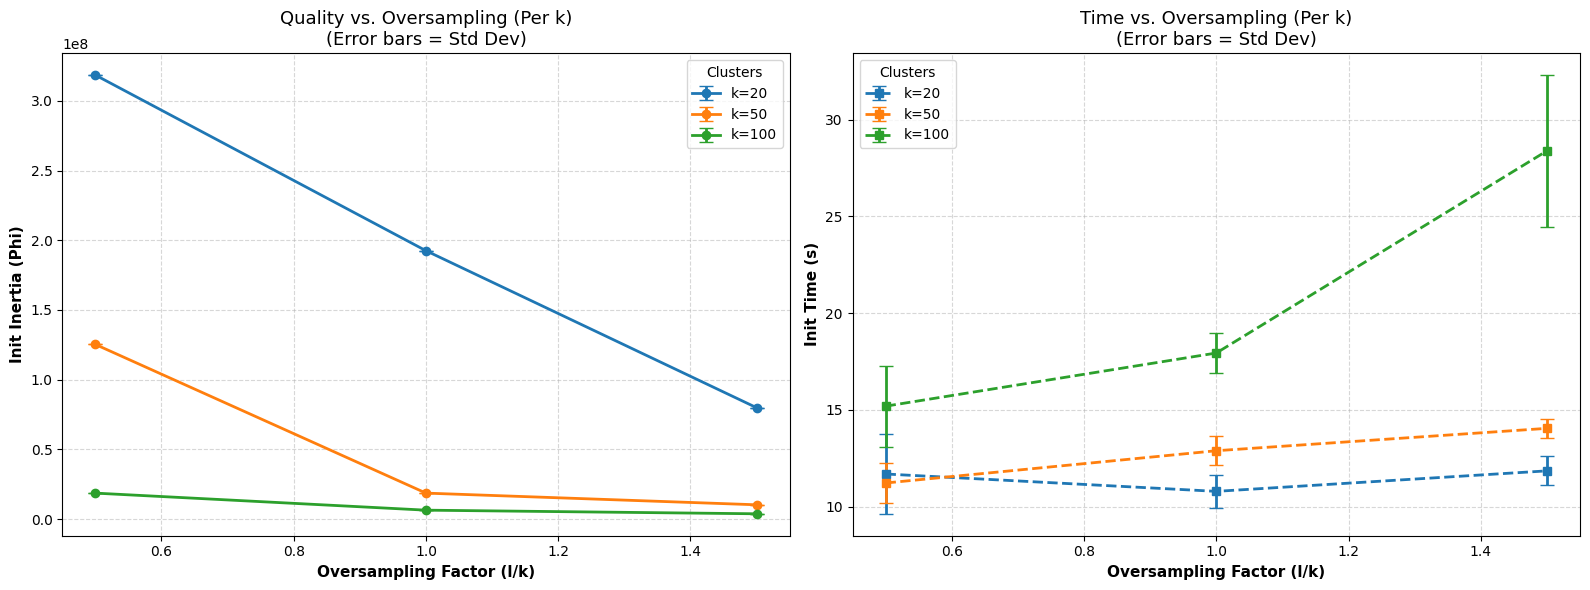

In [97]:
# Setup Data for Plotting
# Sort by k and factor to ensure lines connect correctly in the plot
df_plot = df_final.sort_values(by=["k", "oversampling_factor"])
unique_ks = sorted(df_plot["k"].unique())

# 2. Initialize Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Quality (Inertia) with Error Bars ---
for k in unique_ks:
    subset = df_plot[df_plot["k"] == k]
    ax1.errorbar(
        subset["oversampling_factor"], 
        subset["phi_mean"], 
        yerr=subset["phi_std"],  # <--- Standard Deviation
        marker='o', 
        linewidth=2, 
        capsize=5,               # Adds "caps" to error bars for readability
        label=f"k={k}"
    )

ax1.set_xlabel("Oversampling Factor (l/k)", fontsize=11, fontweight='bold')
ax1.set_ylabel("Init Inertia (Phi)", fontsize=11, fontweight='bold')
ax1.set_title("Quality vs. Oversampling (Per k)\n(Error bars = Std Dev)", fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(title="Clusters")

# --- Plot 2: Cost (Time) with Error Bars ---
for k in unique_ks:
    subset = df_plot[df_plot["k"] == k]
    ax2.errorbar(
        subset["oversampling_factor"], 
        subset["time_mean"], 
        yerr=subset["time_std"], # <--- Standard Deviation
        marker='s', 
        linestyle='--', 
        linewidth=2, 
        capsize=5,
        label=f"k={k}"
    )

ax2.set_xlabel("Oversampling Factor (l/k)", fontsize=11, fontweight='bold')
ax2.set_ylabel("Init Time (s)", fontsize=11, fontweight='bold')
ax2.set_title("Time vs. Oversampling (Per k)\n(Error bars = Std Dev)", fontsize=13)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(title="Clusters")

plt.tight_layout()

# Save the plot
plt.savefig(OUTPUT_PLOT)
print(f"\n[OUTPUT] Plot saved to: {os.path.abspath(OUTPUT_PLOT)}")

plt.show()

As the number of clusters increases, there is an increasing tradeoff between computational time and final potential. In particular, the oversampling factor is less important for many clusters, but it gets heavier on calculations.

#### Ranking & Scoring (without time variance bias)

In [98]:
# Normalize Metrics (Per k-group)
# Scale: 0.0 = Best in its k-group, 1.0 = Worst in its k-group
def normalize_group(x):
    if x.max() == x.min(): return 0.0
    return (x - x.min()) / (x.max() - x.min())

df_rank = df_final.copy()
df_rank['norm_time'] = df_rank.groupby('k')['time_mean'].transform(normalize_group)
df_rank['norm_phi'] = df_rank.groupby('k')['phi_mean'].transform(normalize_group)

# 2. Calculate Scores
# Balanced: 50% Time / 50% Quality
df_rank['score_balanced'] = 0.5 * df_rank['norm_time'] + 0.5 * df_rank['norm_phi']

# Quality Focused: 30% Time / 70% Quality
df_rank['score_quality'] = 0.3 * df_rank['norm_time'] + 0.7 * df_rank['norm_phi']

# Speed Focused: 100% Speed
df_rank['score_speed'] = df_rank['norm_time']

print("="*60)
print("FINAL CONFIGURATION RANKING (Normalized per k)")
print("="*60)

FINAL CONFIGURATION RANKING (Normalized per k)


In [99]:
# --- Helper to print specific winner config ---
def print_winner_config(title, df, sort_col):
    # Sort by score (ascending) and pick the top one
    w = df.sort_values(sort_col).iloc[0]
    
    print(f"\n--- {title} ---")
    print(f"   Hyperparameters:  k={int(w['k'])}, l={w['l']}, rounds={int(w['rounds'])}")
    print(f"   Factor (l/k):     {w['oversampling_factor']:.2f}x")
    print(f"   Time:             {w['time_mean']:.2f}s ± {w['time_std']:.2f}s")
    print(f"   Phi (Inertia):    {w['phi_mean']:.2e} ± {w['phi_std']:.2e}")
    print(f"   Score:            {w[sort_col]:.4f} (Lower is Better)")

# Print Specific Winners
print_winner_config("WINNER: BALANCED TRADEOFF", df_rank, 'score_balanced')
print_winner_config("WINNER: BEST QUALITY", df_rank, 'score_quality')
print_winner_config("WINNER: FASTEST EXECUTION", df_rank, 'score_speed')

# --- Top 10 Table ---
print("\n\n--- Top 10 Configurations (Sorted by Balanced Score) ---")
cols = [
    'k', 'l', 'oversampling_factor', 
    'score_balanced', 'score_quality', 
    'time_mean', 'time_std', 
    'phi_mean', 'phi_std'
]
print(df_rank.sort_values('score_balanced')[cols].head(10).to_string(index=False))

# --- Universal Factor Recommendation ---
avg_factor_score = df_rank.groupby('oversampling_factor')['score_balanced'].mean().idxmin()
print("\n" + "-"*60)
print(f"GLOBAL RECOMMENDATION: The most consistent oversampling factor is {avg_factor_score:.2f}x.")
print(f"For any new k, you should set: l = {avg_factor_score:.2f} * k")
print("-"*60)


--- WINNER: BALANCED TRADEOFF ---
   Hyperparameters:  k=100, l=100.0, rounds=5
   Factor (l/k):     1.00x
   Time:             17.94s ± 1.03s
   Phi (Inertia):    6.43e+06 ± 0.00e+00
   Score:            0.1917 (Lower is Better)

--- WINNER: BEST QUALITY ---
   Hyperparameters:  k=100, l=100.0, rounds=5
   Factor (l/k):     1.00x
   Time:             17.94s ± 1.03s
   Phi (Inertia):    6.43e+06 ± 0.00e+00
   Score:            0.1851 (Lower is Better)

--- WINNER: FASTEST EXECUTION ---
   Hyperparameters:  k=20, l=20.0, rounds=5
   Factor (l/k):     1.00x
   Time:             10.78s ± 0.87s
   Phi (Inertia):    1.92e+08 ± 0.00e+00
   Score:            0.0000 (Lower is Better)


--- Top 10 Configurations (Sorted by Balanced Score) ---
  k     l  oversampling_factor  score_balanced  score_quality  time_mean  time_std    phi_mean  phi_std
100 100.0                  1.0        0.191698       0.185095  17.939254  1.026871   6429228.5 0.000000
 20  20.0                  1.0        0.235975 

### How it scales for different VM setup

In [100]:
# --- CONFIGURATION ---
BASE_DIR = "/MAPD_project/"

# Map Labels to Folder Names
# Make sure these folders match your actual directory names
ARCHITECTURES = {
    "8 Workers": "kdd_results_different_init_4VM_8workers",
    "16 Workers": "kdd_results_different_init_8VM_16workers"
}

OUTPUT_PLOT = "oversampling_comparison_multi_arch.png"

# --- 1. DATA PARSING (MULTI-ARCH) ---
print(f"Scanning {len(ARCHITECTURES)} architectures...")

data_rows = []
filename_pattern = re.compile(r'init_(phi|time)_l_([\d\.]+)_k_(\d+)_rounds_(\d+)_(\d+)\.txt')

for arch_label, folder_name in ARCHITECTURES.items():
    folder_path = os.path.join(BASE_DIR, folder_name)
    
    if not os.path.exists(folder_path):
        print(f"WARNING: Folder not found: {folder_path}")
        continue
        
    print(f"-> Processing: {arch_label}...")
    files = os.listdir(folder_path)
    
    for filename in files:
        match = filename_pattern.search(filename)
        if match:
            try:
                metric = match.group(1)
                l_val = float(match.group(2))
                k_val = int(match.group(3))
                r_val = int(match.group(4))
                rep_idx = int(match.group(5))
                
                with open(os.path.join(folder_path, filename), 'r') as f:
                    content = f.read().strip()
                    clean = content.replace('[', '').replace(']', '').replace(',', ' ').replace('\n', ' ')
                    vals = [float(x) for x in clean.split()]
                    if vals:
                        data_rows.append({
                            'arch': arch_label,
                            'metric': metric,
                            'l': l_val,
                            'k': k_val,
                            'rounds': r_val,
                            'rep': rep_idx,
                            'value': vals[-1]
                        })
            except:
                continue

Scanning 2 architectures...
-> Processing: 8 Workers...
-> Processing: 16 Workers...


In [101]:
# ---  AGGREGATION ---
if not data_rows:
    print("CRITICAL: No data found.")
    exit()

df_raw = pd.DataFrame(data_rows)

# Pivot to get time/phi in one row
df_runs = df_raw.pivot_table(
    index=['arch', 'l', 'k', 'rounds', 'rep'], 
    columns='metric', 
    values='value'
).reset_index().dropna()

# Aggregate Mean/Std
grp_cols = ['arch', 'l', 'k', 'rounds']
df_final = df_runs.groupby(grp_cols).agg({
    'phi': ['mean', 'std'],
    'time': ['mean', 'std']
}).reset_index()

df_final.columns = ['arch', 'l', 'k', 'rounds', 'phi_mean', 'phi_std', 'time_mean', 'time_std']
df_final['oversampling_factor'] = df_final['l'] / df_final['k']

# Sort for clean plotting lines
df_plot = df_final.sort_values(by=["arch", "k", "oversampling_factor"])
unique_ks = sorted(df_plot["k"].unique())
unique_archs = list(ARCHITECTURES.keys()) # Keep order defined in config

print(f"-> Ready to plot {len(df_plot)} configurations.")

-> Ready to plot 18 configurations.



[OUTPUT] Plot saved to: /MAPD_project/oversampling_comparison_multi_arch.png


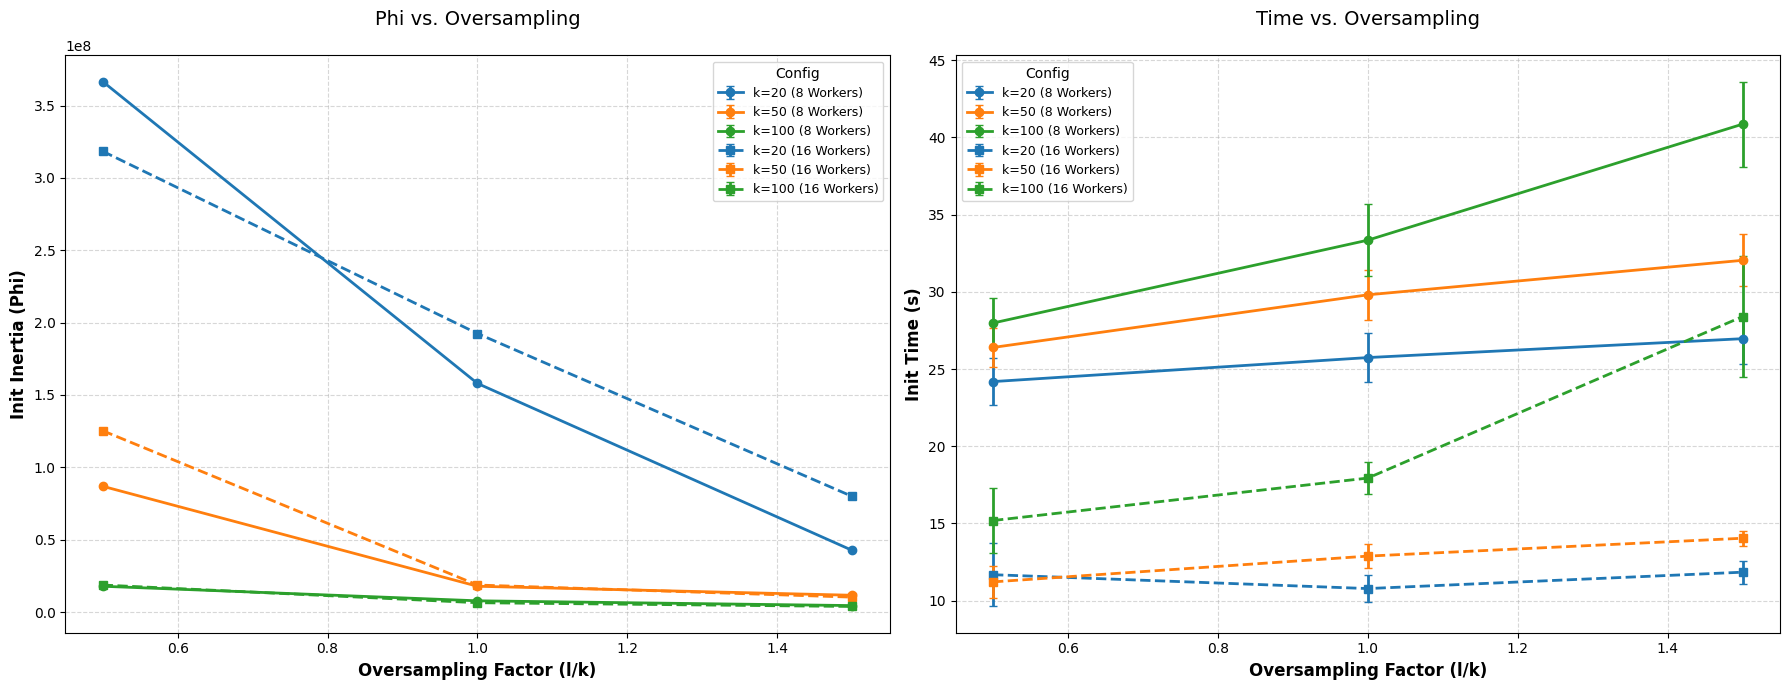

In [102]:
# ---  PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Styling Dictionaries
# Colors for K (Consistent across archs)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red
k_color_map = {k: colors[i % len(colors)] for i, k in enumerate(unique_ks)}

# Linestyles/Markers for Architecture
# 4 Workers = Solid, 8 Workers = Dashed, 16 Workers = Dotted
line_styles = ['-', '--', ':'] 
markers = ['o', 's', '^']
arch_style_map = {}
for i, arch in enumerate(unique_archs):
    arch_style_map[arch] = {
        'ls': line_styles[i % len(line_styles)],
        'marker': markers[i % len(markers)]
    }

# --- Plot Loop ---
for arch in unique_archs:
    for k in unique_ks:
        subset = df_plot[(df_plot["arch"] == arch) & (df_plot["k"] == k)]
        
        if subset.empty: continue
        
        style = arch_style_map[arch]
        color = k_color_map[k]
        
        # Label format: "k=20 (4 Workers)"
        label_str = f"k={k} ({arch})"
        
        # Plot 1: Quality (Inertia)
        ax1.errorbar(
            subset["oversampling_factor"], 
            subset["phi_mean"], 
            yerr=subset["phi_std"], 
            color=color,
            linestyle=style['ls'],
            marker=style['marker'],
            linewidth=2,
            capsize=3,
            label=label_str
        )

        # Plot 2: Time
        ax2.errorbar(
            subset["oversampling_factor"], 
            subset["time_mean"], 
            yerr=subset["time_std"], 
            color=color,
            linestyle=style['ls'],
            marker=style['marker'],
            linewidth=2,
            capsize=3,
            label=label_str
        )

# --- Formatting ---

# AX1: Quality
ax1.set_xlabel("Oversampling Factor (l/k)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Init Inertia (Phi)", fontsize=12, fontweight='bold')
ax1.set_title("Phi vs. Oversampling\n", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)
# Legend sorted by k
handles, labels = ax1.get_legend_handles_labels()
# Optional: Sort legend to group by K or Arch if needed, currently plots order
ax1.legend(handles, labels, title="Config", fontsize=9, loc='upper right')

# AX2: Time
ax2.set_xlabel("Oversampling Factor (l/k)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Init Time (s)", fontsize=12, fontweight='bold')
ax2.set_title("Time vs. Oversampling\n", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(handles, labels, title="Config", fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_PLOT)
print(f"\n[OUTPUT] Plot saved to: {os.path.abspath(OUTPUT_PLOT)}")
plt.show()

Dashed lines represent the architecture with 16 workers. We can see how it doesn't change the inertia of the initialization, but it has a sensible speed up for the computation time.

### Conclusions  

During this project, we developed two parallelized versions of the K-Means algorithm. We initially implemented a purely parallel approach in a local setting, which led us to believe that straightforward parallelization would be sufficient. However, when transitioning to a distributed environment, we encountered memory limitations that made this approach impractical.  

To address this, we implemented a **MiniBatch K-Means** version combined with the **kmeans++ initialization** strategy. We then performed hyperparameter tuning over the following ranges:  

- **Batch size:** [25 000, 50 000, 100 000, 150 000, 200 000]  
- **Number of clusters:** [20, 35, 50, 75, 100]  
- **Initialization rounds:** [5, 6, 7]  
- **Initialization oversampling:** [10, 20, 35, 40, 50, 75, 100, 150, 200]  
- **Iterations:** [5, 10, 20]  
- **Number of VMs:** [4, 8]  
- **Workers:** [4, 8, 16]  

We then investigated the scaling capabilities of our algorithm and observed a **sub-linear scaling behavior**. Although increasing the number of workers reduced execution time, the achieved speedup was far from ideal due to overhead and synchronization costs inherent in distributed computation, still our analysis in this context can be easly improved. We limited us to observe the average scaling over architectures, we think we can observe a better scaling considering our best models  

Next, we selected a potential *best model* by normalizing the dataset over \(k\) in order to compare runs with the same hyperparameters but different cluster sizes. We applied a Pareto-based criterion, assigning the inertia a weight twice as large as execution time. The selected configuration was:  


blk = 32, r = 5, it = 10, bs = 150000, workers = 16.


Using this model, we analyzed the convergence properties of our algorithm and the advantages of kmeans|| over random initialization. We observed that most of the effective clustering is achieved during initialization, which is crucial to obtain results comparable to vanilla K-Means. MiniBatch K-Means then refines the solution, albeit with a noisier convergence due to its stochastic nature.  

Finally, we attempted to identify an optimal value of \(k\) by searching for a saturation point in the inertia curve. However, the structure of the dataset does not exhibit a clear elbow, making the selection of an optimal number of clusters non-trivial.
